### Libraries

In [1]:
import pyreadstat
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import chi2
from scipy.stats import chi2_contingency
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
from mpl_toolkits.mplot3d import Axes3D
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
import geopandas as gpd

2026-01-09 16:14:06.746351: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-09 16:14:08.841434: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-09 16:14:12.864885: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Load data

In [2]:
# df_ch = pd.read_spss(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.sav")      #Local dataset
df_ch = pd.read_spss('/workspaces/malnutrition/Dataset/ch.sav')
df_ch.head(2)

,HH1,HH2,LN,UF1,UF2,UF3,UFINT,UF4,UF5,UF6,...,wscoreu,windex5u,windex10u,wscorer,windex5r,windex10r,ListCat,PSU,dstratum,stratum
0,1.0,3.0,5.0,1.0,3.0,5.0,103.0,4.0,103.0,100.0,...,NaN,NaN,NaN,-0.831559,Second,3rd decile,With child U5 during listing,1.0,"U5 HH, Province 1 Rural",Province 1 Rural
1,1.0,5.0,5.0,1.0,5.0,5.0,104.0,2.0,104.0,100.0,...,NaN,NaN,NaN,-1.220021,Poorest,2nd decile,With child U5 during listing,1.0,"U5 HH, Province 1 Rural",Province 1 Rural


In [4]:
import pandas as pd

# Show all columns when printing
pd.set_option('display.max_rows', None)

# Count and sort missing values
print(df_ch.isna().sum().sort_values(ascending=True))

UFINT              0
UF4                0
UF5                0
UF6                0
UF7D               0
dstratum           0
UB10C              0
UB10D              0
CA11C              0
UB10X              0
UB10NR             0
CA11B              0
CA11E              0
CA11D              0
CA11H              0
CA11I              0
EC5AB              0
HH2                0
LN                 0
UF1                0
UF2                0
UF3                0
PSU                0
EC5AA              0
EC5BA              0
EC5AX              0
EC5AY              0
EC5ANR             0
EC5BX              0
EC5BB              0
EC5BY              0
EC5BNR             0
CA11A              0
CA9E               0
CA9H               0
CA9I               0
CA9J               0
CA9K               0
CA9L               0
CA9M               0
CA9O               0
CA9W               0
CA9P               0
CA9Q               0
CA9R               0
CA9X               0
CA9Z               0
CA9NR        

## Rename variables and remove the coded entries

In [9]:
# Renaming the columns
feature_coded = df_ch[['EC3A', 'EC3B', 'AN4', 'AN8', 'CA1', 'CA14', 'HH6', 'HL4', 'melevel1', 'cinsurance', 'HH7c', 'windex5', 'WAZ2', 'HAZ2', 'WHZ2']]
df1 = feature_coded.rename(columns={
    'EC3A': 'Days left alone',
    'EC3B': 'Left for Another Care',
    'AN4': 'child age',
    'AN8': 'child weight',
    # 'BD2': 'ever breastfed',
    'CA1': 'diarrhoea',
    'CA14': 'fever',
    'HH6': 'area',
    'HL4': 'child sex',
    'melevel1': 'mother education',
    'cinsurance': 'health insurance',
    'HH7c': 'province',
    'windex5': 'wealth index',
    'WAZ2': 'underweight',
    'HAZ2': 'stunting',
    'WHZ2': 'wasting'
})

# Remove rows with coded entries in each column
coded_child_weight = ['OTHER', 'CHILD REFUSED', 'CHILD NOT PRESENT', 'RESPONDENT REFUSED']
coded_underweight = ['Z-score out of range', 'Not measured', 'Measurement out of range']
coded_stunting = ['Not measured', 'Measurement out of range']
coded_wasting = ['Measurement out of range', ' Measurement out of range', 'Not measured']
coded_diarrhoea = ['DK', 'NO RESPONSE']
coded_fever = ['DK']
coded_insurance = ['Missing/DK']
coded_wealth_index = [0.0]
coded_mother_education = ['Missing/DK']

df1 = df1[~df1['child weight'].isin(coded_child_weight)]
df1 = df1[~df1['underweight'].isin(coded_underweight)]
df1 = df1[~df1['stunting'].isin(coded_stunting)]
df1 = df1[~df1['wasting'].isin(coded_wasting)] 
df1 = df1[~df1['diarrhoea'].isin(coded_diarrhoea)]
df1 = df1[~df1['fever'].isin(coded_fever)]
df1 = df1[~df1['health insurance'].isin(coded_insurance)]
df1 = df1[~df1['wealth index'].isin(coded_wealth_index)]
df1 = df1[~df1['mother education'].isin(coded_mother_education)]

# Drop missing values and make a copy to avoid chained assignment issues
df1.dropna()
df1.head(2)

,Days left alone,Left for Another Care,child age,child weight,diarrhoea,fever,area,child sex,mother education,health insurance,province,wealth index,underweight,stunting,wasting
0,NONE,NONE,1.0,7.8,NO,NO,RURAL,MALE,Secondary (Gr 9-12),Without insurance,Province 1,Poorest,-2.94,-3.53,-1.69
1,NONE,NONE,3.0,12.5,NO,YES,RURAL,MALE,Secondary (Gr 9-12),Without insurance,Province 1,Poorest,-1.93,-2.58,-0.65


In [10]:
df1['Left for Another Care'].value_counts()

Left for Another Care
NONE           5405
7.0             278
2.0             258
1.0             213
3.0             135
5.0             108
4.0              81
DK               36
6.0              35
NO RESPONSE       3
Name: count, dtype: int64

Ever breastfed has 2940 missing entries and this variable has very weak significance supported by cramer's v test and feature importance check.

In [12]:
df2 = df1.copy()
df2['underweight'] = pd.to_numeric(df2['underweight'], errors='coerce')
df2['stunting'] = pd.to_numeric(df2['stunting'], errors='coerce')
df2['wasting'] = pd.to_numeric(df2['wasting'], errors='coerce')

# Convert to Binary Response Variables
df2['underweight'] = [0 if -2 <= x < 2 else 1 for x in df2['underweight']]
df2['stunting'] = [0 if -2 <= x < 2 else 1 for x in df2['stunting']]
df2['wasting'] = [0 if -2 <= x < 2 else 1 for x in df2['wasting']]

df2['status'] = df2[['underweight', 'stunting', 'wasting']].apply(lambda x: 1 if any(i == 1 for i in x) else 0, axis=1) # Create 'status' as a new response variable

In [70]:
# print(df2['child_weight'].value_counts().to_string())

In [13]:
# Rename province names
province_mapping = {
    "Province 1": "koshi",
    "Province 2": "madhesh",
    "Bagmati Province": "bagmati",
    "Gandaki Province": "gandaki",
    "Province 5": "lumbini",
    "Karnali Province": "karnali",
    "Sudoorpaschim Province": "sudurpashchim"
}

# Apply the mapping
df2['province'] = df2['province'].cat.rename_categories(province_mapping)
df2.head(2)

,child age,child weight,diarrhoea,fever,area,child sex,mother education,health insurance,province,wealth index,underweight,stunting,wasting,status
0,1.0,7.8,NO,NO,RURAL,MALE,Secondary (Gr 9-12),Without insurance,koshi,Poorest,1,1,0,1
1,3.0,12.5,NO,YES,RURAL,MALE,Secondary (Gr 9-12),Without insurance,koshi,Poorest,0,1,0,1


In [14]:
df3 = df2.drop(['underweight', 'stunting', 'wasting'], axis=1)
df3.head(2)

,child age,child weight,diarrhoea,fever,area,child sex,mother education,health insurance,province,wealth index,status
0,1.0,7.8,NO,NO,RURAL,MALE,Secondary (Gr 9-12),Without insurance,koshi,Poorest,1
1,3.0,12.5,NO,YES,RURAL,MALE,Secondary (Gr 9-12),Without insurance,koshi,Poorest,1


In [15]:
# Copy your original DataFrame
df_encoded = df3.copy()

# Label Encoding for binary categories
binary_cols = [
    'diarrhoea',
    'fever',
    'area',
    'child sex',
    'health insurance'
]
le = LabelEncoder()
for col in binary_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Ordinal encoding for ordinal category (mother education)
edu_order = {
    'None': 0,
    'Basic (Gr 1-8)': 1,
    'Secondary (Gr 9-12)': 2,
    'Higher': 3
}
df_encoded['mother education'] = df3['mother education'].map(edu_order)

# Ordinal encoding for ordinal category (wealth index)
wealth_order = {
    'Poorest': 1,
    'Second': 2,
    'Middle': 3,
    'Fourth': 4,
    'Richest': 5
}
df_encoded['wealth index'] = df3['wealth index'].map(wealth_order)

# Convert child_weight to float if it's actually numeric
df_encoded['child weight'] = pd.to_numeric(df1['child weight'], errors='raise')

df_encoded.head()


,child age,child weight,diarrhoea,fever,area,child sex,mother education,health insurance,province,wealth index,status
0,1.0,7.8,0,0,0,1,2.0,1,koshi,1.0,1
1,3.0,12.5,0,1,0,1,2.0,1,koshi,1.0,1
2,2.0,11.1,1,0,0,0,1.0,1,koshi,1.0,0
3,1.0,9.3,1,1,0,0,1.0,1,koshi,1.0,0
4,4.0,14.7,0,0,0,0,1.0,1,koshi,1.0,0


In [74]:
df_encoded['province'].value_counts()

province
bagmati          1199
madhesh          1074
lumbini           995
koshi             951
sudurpashchim     843
karnali           770
gandaki           720
Name: count, dtype: int64

In [75]:
vc = df1['health insurance'].value_counts()
vc_pct = df1['health insurance'].value_counts(normalize=True) * 100

summary = vc.astype(str) + " (" + vc_pct.round(2).astype(str) + ")"
print(summary)

health insurance
Without insurance    6262 (95.57)
With insurance         290 (4.43)
Missing/DK                0 (0.0)
dtype: object


### One-hot encode to nominal feature

In [76]:
# One-hot encoding for province (nominal)
df_one_hot_encoded = pd.get_dummies(df_encoded, columns=['province'], drop_first=True)
df_one_hot_encoded = df_one_hot_encoded.astype({col: int for col in df_one_hot_encoded.columns if df_one_hot_encoded[col].dtype == 'bool'})

# Remove province_ in columns name
df_one_hot_encoded.columns = df_one_hot_encoded.columns.str.replace('province_', '')


## Standardize continuous feature

In [77]:
# Standardize childe weight
df = df_one_hot_encoded.copy()
scaler = StandardScaler()
df['child weight'] = scaler.fit_transform(df[['child weight']])
df.head(2)

,child age,child weight,diarrhoea,fever,area,child sex,mother education,health insurance,wealth index,status,gandaki,karnali,koshi,madhesh,lumbini,sudurpashchim
0,1.0,-1.066081,0,0,0,1,2.0,1,1.0,1,0,0,1,0,0,0
1,3.0,0.434428,0,1,0,1,2.0,1,1.0,1,0,0,1,0,0,0


## Childern counts vs malnutrition status

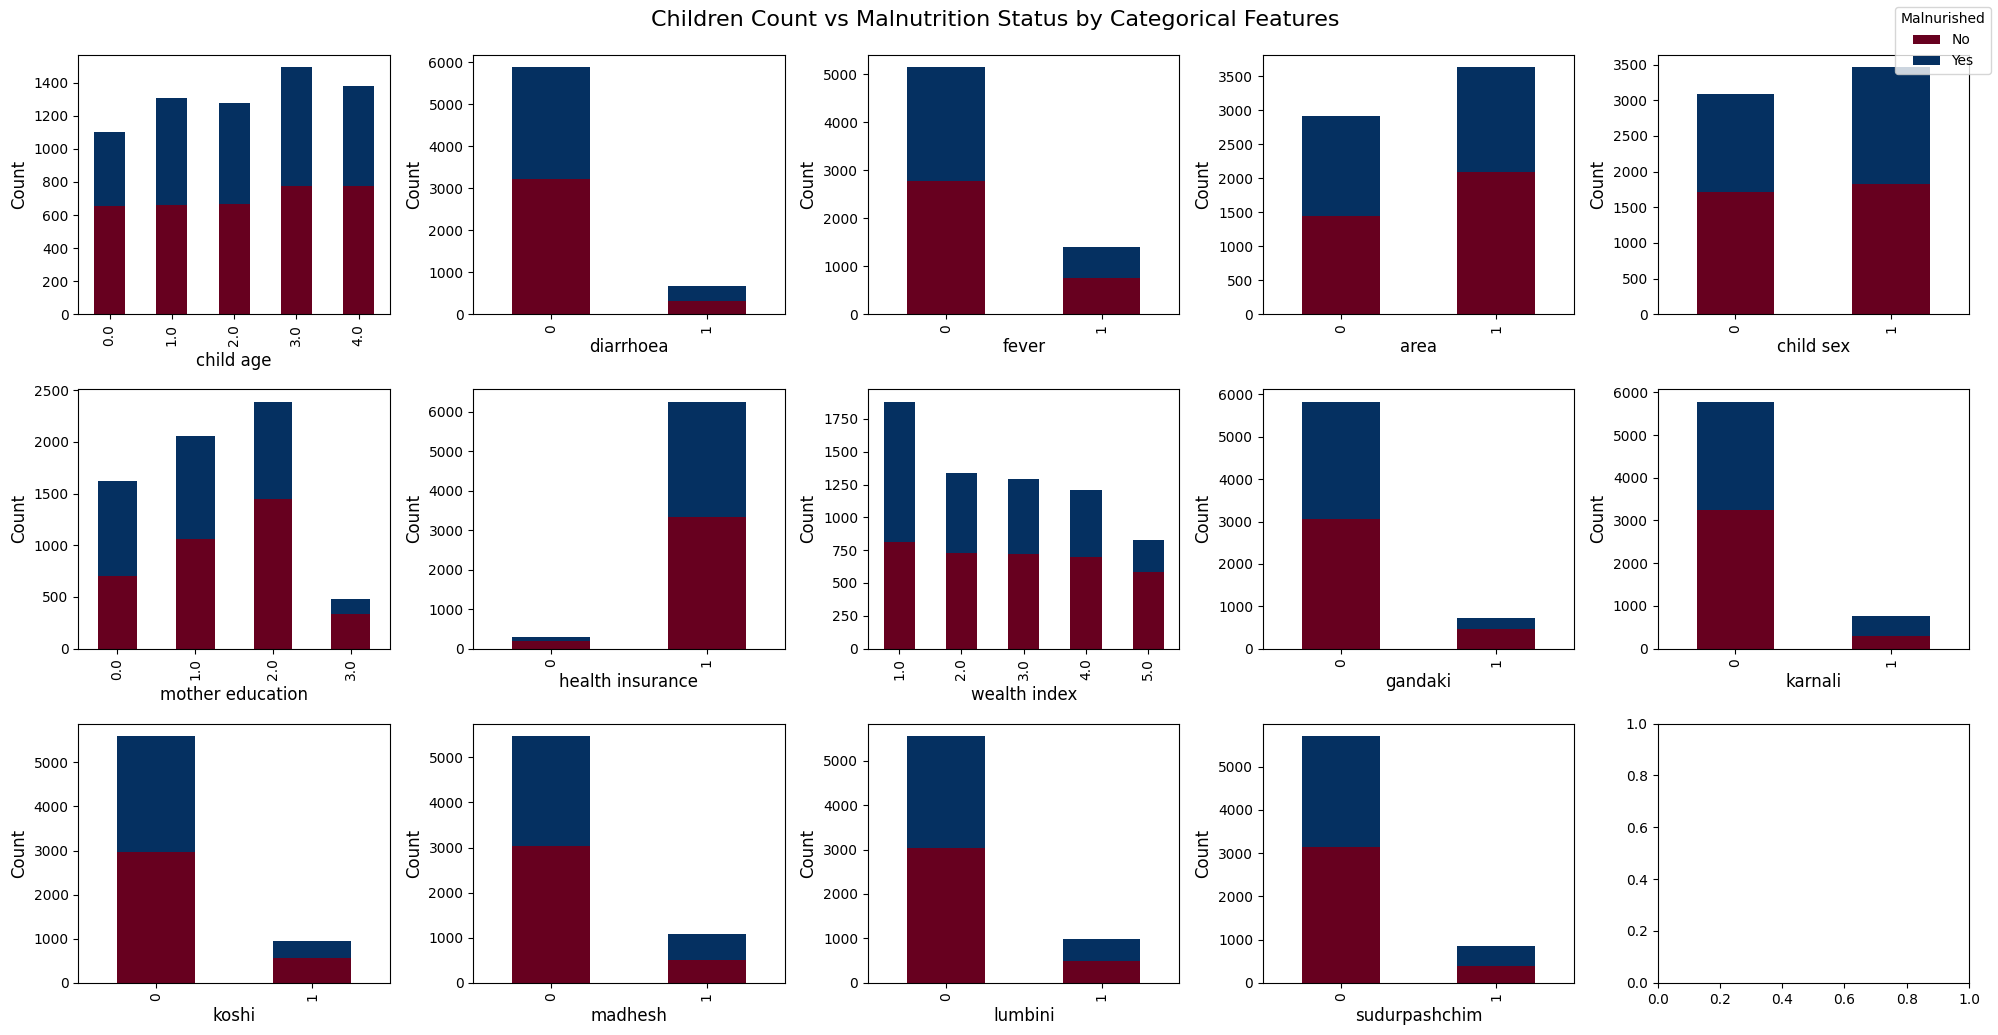

In [78]:
# List of features to plot
features = [
    'child age', 'diarrhoea', 'fever', 'area', 'child sex', 'mother education', 'health insurance', 'wealth index', 'gandaki', 'karnali', 'koshi',	'madhesh',	'lumbini',	'sudurpashchim'
]

# Set up a grid for 2 rows × 4 columns
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(20, 10))

# Flatten axes for easy iteration
axes = axes.flatten()

for i, feature in enumerate(features):
    ctab = pd.crosstab(df[feature], df['status'])
    ctab.plot(kind='bar', stacked=True, colormap='RdBu', ax=axes[i], legend=False)
    axes[i].set_ylabel("Count", fontsize=12)
    axes[i].set_xlabel(feature, fontsize=12)

# Add one global legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['No', 'Yes'], title='Malnurished', loc='upper right')

plt.tight_layout()
plt.suptitle("Children Count vs Malnutrition Status by Categorical Features", fontsize=16, y=1.03)
plt.show()

### Violinplot of continuous feature

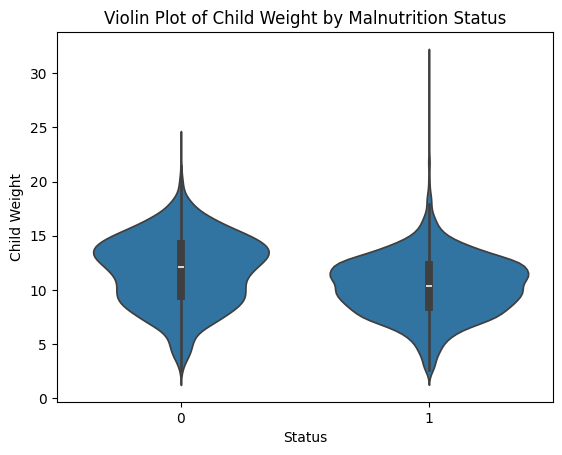

In [79]:
sns.violinplot(x='status', y='child weight', data=df_one_hot_encoded)
plt.title("Violin Plot of Child Weight by Malnutrition Status")
plt.xlabel("Status")
plt.ylabel("Child Weight")
plt.show()

## Feature Importance Check for Categorical Features

### Contingency table for categorical features

In [80]:
vc = df['child age'].value_counts()
vc_pct = df['child age'].value_counts(normalize=True) * 100

summary = vc.astype(str) + " (" + vc_pct.round(2).astype(str) + ")"
print(summary)

child age
3.0    1492 (22.77)
4.0    1380 (21.06)
1.0     1304 (19.9)
2.0    1276 (19.47)
0.0    1100 (16.79)
dtype: object


In [81]:
# Listing all categorical features
cat_columns = [
    'child age', 'diarrhoea', 'fever', 'area', 'child sex', 'mother education', 'health insurance', 'wealth index', 'gandaki', 'karnali', 'koshi',	'madhesh',	'lumbini',	'sudurpashchim'
]

# Contingency table for categorical features
for col in cat_columns:
    table = pd.crosstab(df[col], df['status'], margins=False)

    # Calculate row-wise percentages
    row_pct = table.div(table.sum(axis=1), axis=0) * 100
    row_pct = row_pct.round(1)  # Round to 1 decimal

    # Combine count and percentage for pretty output
    combined = table.astype(str) + " (" + row_pct.astype(str) + ")"

    print(f"\nContingency table for {col}:\n{combined}\n")



Contingency table for child age:
status              0           1
child age                        
0.0        657 (59.7)  443 (40.3)
1.0        662 (50.8)  642 (49.2)
2.0        666 (52.2)  610 (47.8)
3.0        777 (52.1)  715 (47.9)
4.0        773 (56.0)  607 (44.0)


Contingency table for diarrhoea:
status               0            1
diarrhoea                          
0          3210 (54.6)  2667 (45.4)
1           325 (48.1)   350 (51.9)


Contingency table for fever:
status            0            1
fever                           
0       2788 (54.2)  2360 (45.8)
1        747 (53.2)   657 (46.8)


Contingency table for area:
status            0            1
area                            
0       1445 (49.5)  1476 (50.5)
1       2090 (57.6)  1541 (42.4)


Contingency table for child sex:
status               0            1
child sex                          
0          1711 (55.4)  1379 (44.6)
1          1824 (52.7)  1638 (47.3)


Contingency table for mother education:
sta

In [82]:
X_cat = df[cat_columns].copy()
y = df['status']

# # Label encode all categorical variables if needed
# for col in X_cat.columns:
#     if X_cat[col].dtype == 'object':
#         X_cat[col] = LabelEncoder().fit_transform(X_cat[col])

chi_vals, p_vals = chi2(X_cat, y)

chi_df = pd.DataFrame({'Feature': X_cat.columns, 'Chi2': chi_vals, 'p-value': p_vals})
print(chi_df.sort_values(by='Chi2', ascending=False))


             Feature        Chi2       p-value
7       wealth index  121.289475  3.302509e-28
5   mother education  107.392252  3.652316e-25
9            karnali   69.661074  7.042223e-17
8            gandaki   38.085818  6.770041e-10
13     sudurpashchim   23.278844  1.401330e-06
11           madhesh   23.068611  1.563220e-06
3               area   19.014275  1.297442e-05
10             koshi   15.701375  7.417024e-05
1          diarrhoea    9.155200  2.480123e-03
12           lumbini    5.488034  1.914706e-02
4          child sex    2.235867  1.348410e-01
6   health insurance    1.163027  2.808386e-01
0          child age    0.929861  3.348991e-01
2              fever    0.316078  5.739741e-01


### Cramer's V Test
$
V = \sqrt{ \frac{\chi^2 / n}{\min(k - 1, r - 1)} }
$

In [83]:
cramers_v_results = {}

for col in cat_columns:
    if col != 'status':
        table = pd.crosstab(df[col], df['status'])
        chi2, _, _, _ = chi2_contingency(table)
        n = table.sum().sum()
        phi2 = chi2 / n
        r, k = table.shape
        dof = min(k - 1, r - 1)
        V = np.sqrt(phi2 / dof)

        cramers_v_results[col] = V
        # print(f"{col}: Cramér's V = {V:.4f}")

cramers_v_sorted = pd.Series(cramers_v_results).sort_values(ascending=False)
print(cramers_v_sorted)

wealth index        0.168761
mother education    0.157582
karnali             0.109288
area                0.080374
gandaki             0.080322
madhesh             0.064480
sudurpashchim       0.063399
child age           0.063178
health insurance    0.062584
koshi               0.052512
diarrhoea           0.038965
lumbini             0.030999
child sex           0.026593
fever               0.007463
dtype: float64


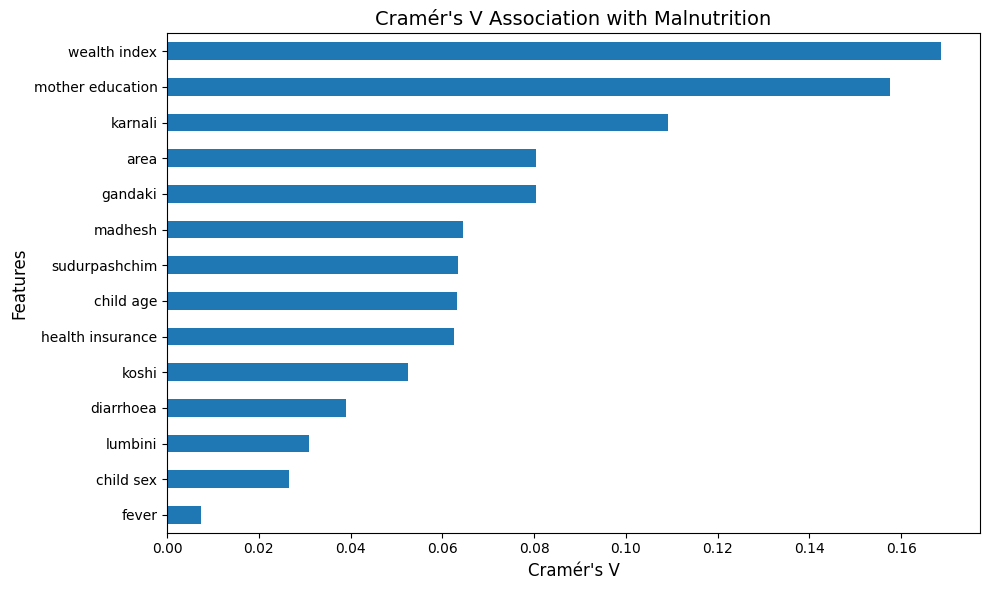

In [84]:
# Plotting the sorted Cramér's V values
plt.figure(figsize=(10, 6))
cramers_v_sorted.plot(kind='barh')

plt.title("Cramér's V Association with Malnutrition", fontsize=14)
plt.xlabel("Cramér's V", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.gca().invert_yaxis()  # Highest at the top
plt.grid(False)
plt.tight_layout()
plt.show()

## Data visualization

c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


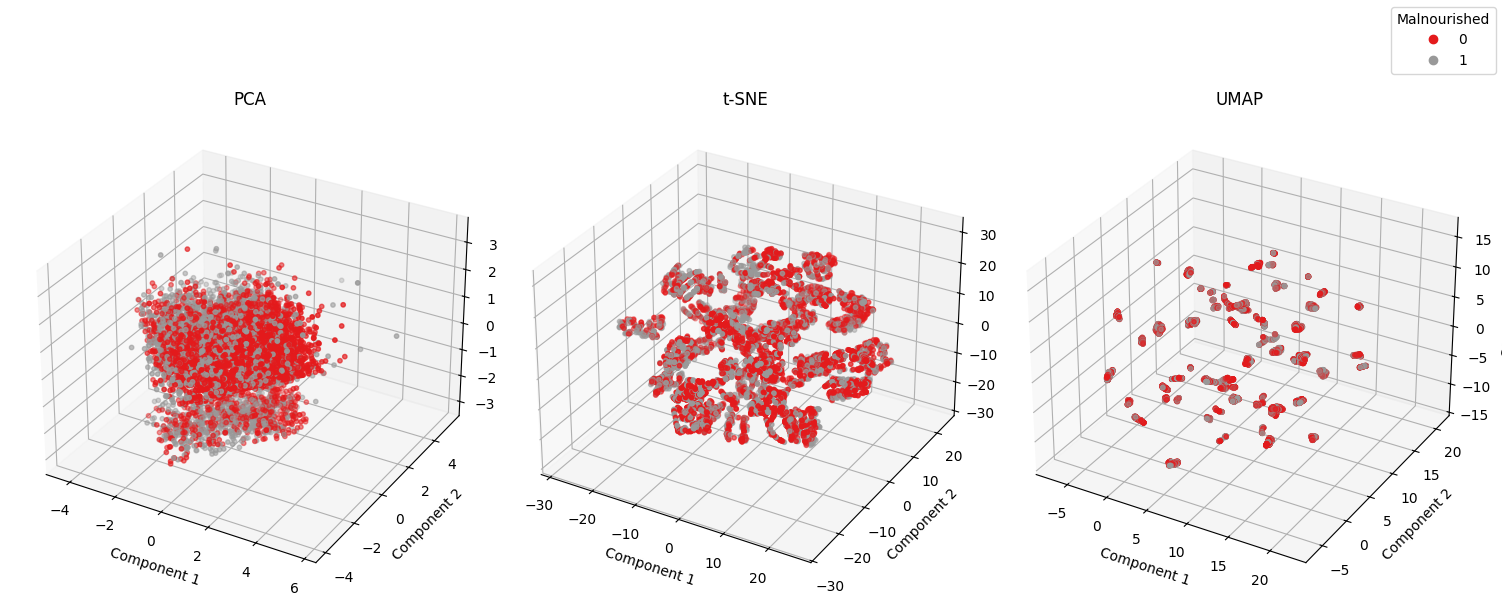

In [21]:
# Encode and scale the dataset
X = pd.get_dummies(df.drop(columns='status'), drop_first=True)
y = df['status']
X_scaled = StandardScaler().fit_transform(X)

# Reduce with PCA (3D)
X_pca = PCA(n_components=3).fit_transform(X_scaled)

# Reduce with t-SNE (3D)
X_tsne = TSNE(n_components=3, random_state=42).fit_transform(X_scaled)

# Reduce with UMAP (3D)
X_umap = umap.UMAP(n_components=3, random_state=42).fit_transform(X_scaled)

# Plot
fig = plt.figure(figsize=(15, 7))

# PCA
ax1 = fig.add_subplot(131, projection='3d')
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y, cmap='Set1', s=10)
ax1.set_title("PCA")
ax1.set_xlabel("Component 1")
ax1.set_ylabel("Component 2")
ax1.set_zlabel("Component 3")

# t-SNE
ax2 = fig.add_subplot(132, projection='3d')
scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2], c=y, cmap='Set1', s=10)
ax2.set_title("t-SNE")
ax2.set_xlabel("Component 1")
ax2.set_ylabel("Component 2")
ax2.set_zlabel("Component 3")

# UMAP
ax3 = fig.add_subplot(133, projection='3d')
scatter3 = ax3.scatter(X_umap[:, 0], X_umap[:, 1], X_umap[:, 2], c=y, cmap='Set1', s=10)
ax3.set_title("UMAP")
ax3.set_xlabel("Component 1")
ax3.set_ylabel("Component 2")
ax3.set_zlabel("Component 3")

# Legend (common)
fig.legend(*scatter1.legend_elements(), title="Malnourished", loc="upper right")
# fig.suptitle("3D PCA vs t-SNE vs UMAP Projection of Dataset", fontsize=16)
plt.tight_layout()
plt.show()

## Save final data

In [22]:
# df.to_csv(r'C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv', index=False)

---

## Boruta Algorithm for feature selection

In [23]:
# Separate features and target
X = df.drop(columns='status')
y = df['status']

# Convert to numpy arrays (Boruta requires numpy arrays)
X_np = X.values
y_np = y.values

# Define the RandomForest model for Boruta
rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5, random_state=42)

# Initialize Boruta
boruta_selector = BorutaPy(
    estimator=rf,
    n_estimators='auto',
    verbose=2,
    random_state=42
)

# Fit Boruta
boruta_selector.fit(X_np, y_np)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	5
Tentative: 	0
Rejected: 	10


BorutaPy finished running.

Iteration: 	9 / 100
Confirmed: 	5
Tentative: 	0
Rejected: 	10


BorutaPy(estimator=RandomForestClassifier(class_weight='balanced', max_depth=5,
                                          n_estimators=109, n_jobs=-1,
                                          random_state=RandomState(MT19937) at 0x125B6CF7940),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x125B6CF7940, verbose=2)

In [24]:

# Get selected feature names
selected_features = X.columns[boruta_selector.support_].tolist()
print("Selected Features by Boruta:")
print(selected_features)

Selected Features by Boruta:
['child age', 'child weight', 'mother education', 'wealth index', 'karnali']


_______

In [25]:
# Get feature rankings for all features
feature_ranks = pd.DataFrame({
    'Feature': X.columns,
    'Rank': boruta_selector.ranking_
}).sort_values(by='Rank')

print(feature_ranks)


             Feature  Rank
0          child age     1
1       child weight     1
6   mother education     1
8       wealth index     1
10           karnali     1
4               area     2
9            gandaki     2
12           madhesh     2
14     sudurpashchim     4
11             koshi     5
7   health insurance     6
13           lumbini     7
5          child sex     8
2          diarrhoea     9
3              fever    10


## Provincewise status

### From our dataset

In [26]:
# Compute percentages of stunting, underweight, and wasting by province from the dataset
province_wise = (
    df2.groupby('province', observed=True)[['stunting', 'underweight', 'wasting', 'status']]
    .mean()
    .multiply(100)
    .reset_index()
    .rename(columns={'stunting': 'stunting %',
                     'underweight': 'underweight %',                     
                     'wasting': 'wasting %',
                     'status': 'status %'})
).round(2)
province_wise

# province_wise.to_csv(r'C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\provincewise percentage.csv', index=False) #Export to csv

,province,stunting %,underweight %,wasting %,status %
0,bagmati,27.69,14.26,9.92,32.94
1,gandaki,26.11,15.42,10.97,34.58
2,karnali,48.31,35.97,21.56,61.04
3,koshi,28.39,20.08,14.72,39.64
4,madhesh,41.34,29.61,22.63,53.35
5,lumbini,37.09,29.85,15.68,49.75
6,sudurpashchim,42.94,33.69,17.32,54.33


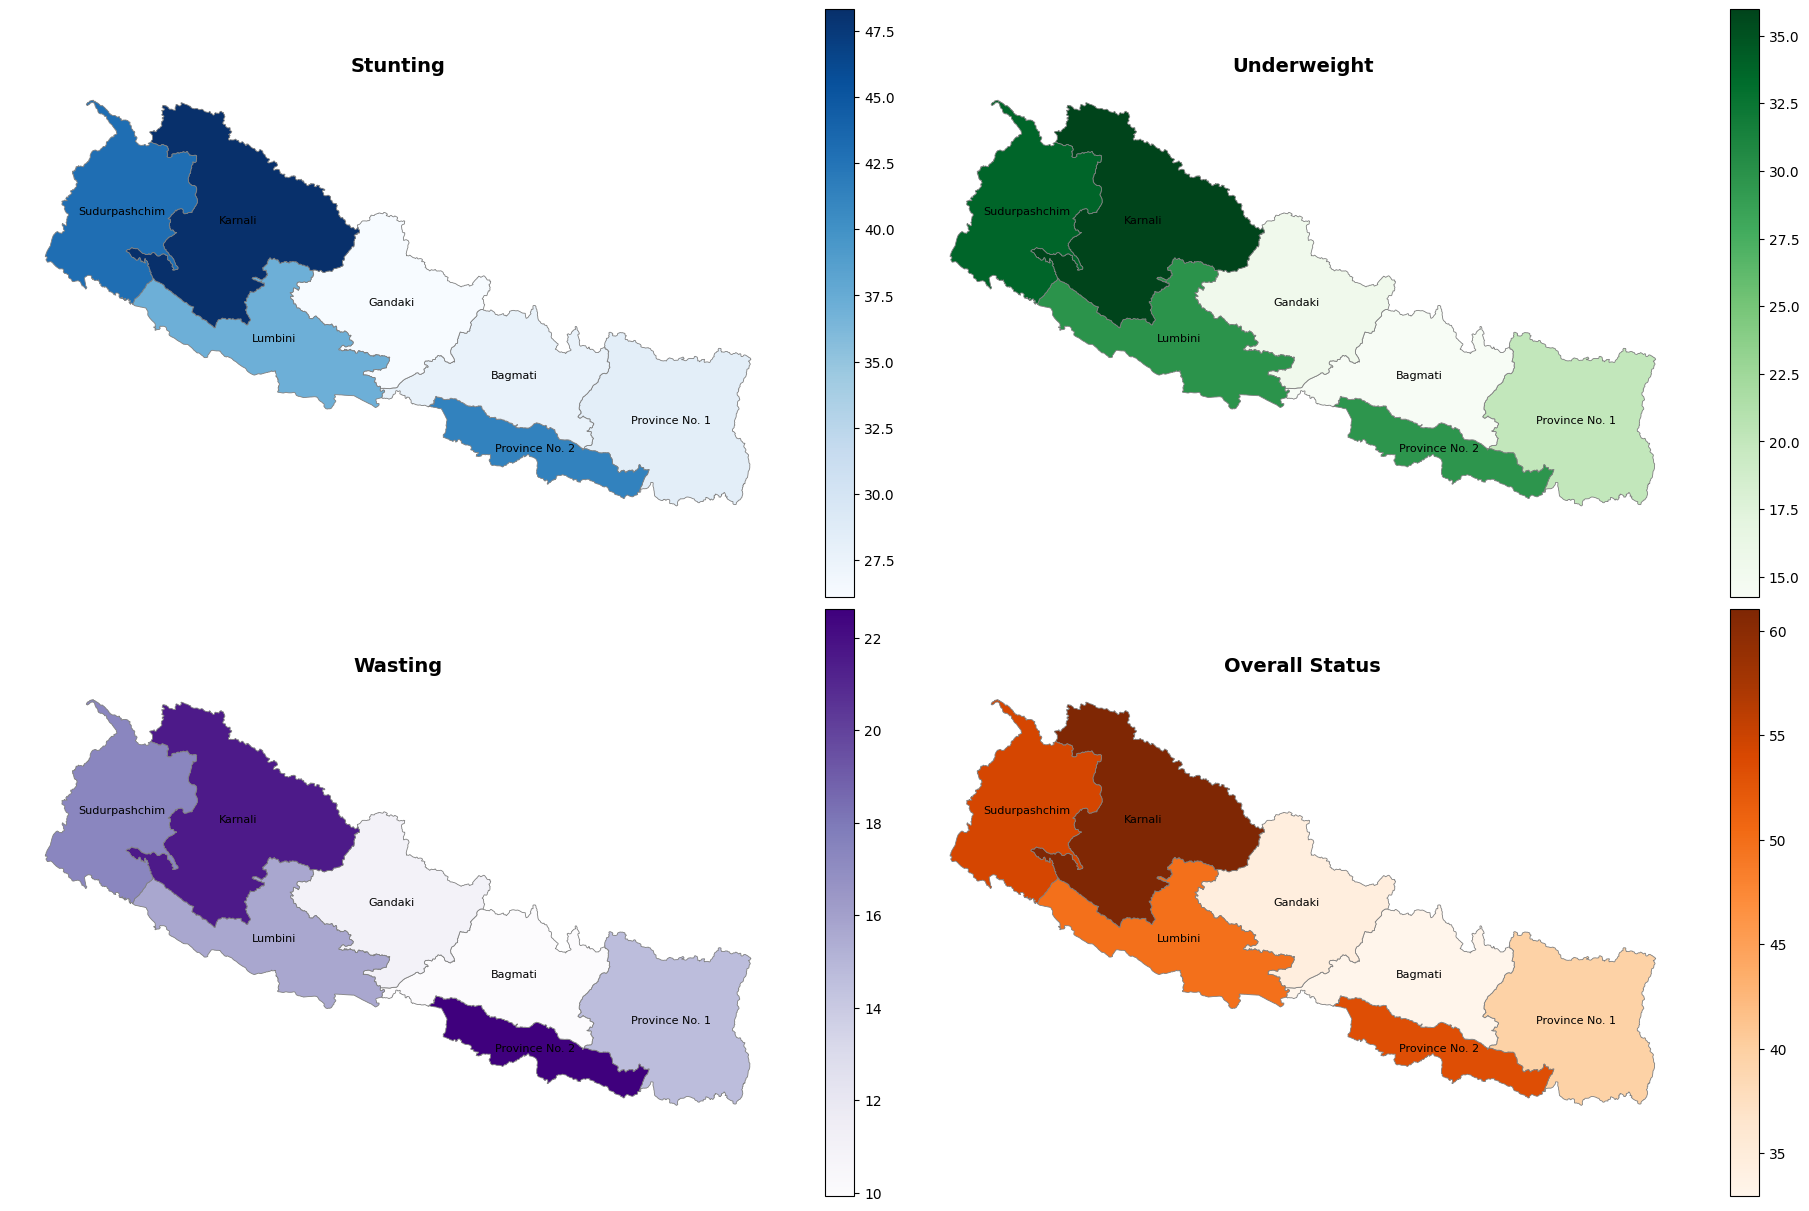

In [27]:
import geopandas as gpd

# Step 1: Load GeoJSON and prepare data
gdf = gpd.read_file(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\nepal_admin1.geojson")  # name of downloaded file
gdf = gdf.rename(columns={"name": "province"})

# Step 2: Your data
data = {
    'province': ['Province No. 1', 'Province No. 2', 'Bagmati', 'Gandaki',
                 'Lumbini', 'Karnali', 'Sudurpashchim'],
    'Stunting': [28.39, 41.34, 27.69, 26.11, 37.09, 48.31, 42.94],
    'Underweight': [20.08, 29.61, 14.26, 15.42, 29.85, 35.97, 33.69],
    'Wasting': [14.72, 22.63, 9.92, 10.97, 15.68, 21.56, 17.32],
    'Status': [39.64, 53.35, 32.94, 34.58, 49.75, 61.04, 54.33]
}
df_data = pd.DataFrame(data)

# Step 3: Merge with geodata
merged = gdf.merge(df_data, on='province')

# Step 4: Create 2x2 plot grid
fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)

cols = ['Stunting', 'Underweight', 'Wasting', 'Status']
cmaps = ['Blues', 'Greens', 'Purples', 'Oranges']
titles = ['Stunting', 'Underweight', 'Wasting', 'Overall Status']

# Flatten the axes for easy iteration
axes = axes.flatten()

for ax, col, cmap, title in zip(axes, cols, cmaps, titles):
    merged.plot(
        column=col, cmap=cmap, linewidth=0.6,
        edgecolor='gray', legend=True, ax=ax
    )
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

# Step 5: Add province names at centroids
for idx, row in merged.iterrows():
    centroid = row['geometry'].centroid
    for ax in axes:
        ax.text(centroid.x, centroid.y, row['province'], fontsize=8,
                ha='center', va='center', color='black')

plt.show()


## Percentage of children who are malnourished

In [28]:
malnourished_cols = ['stunting', 'underweight', 'wasting', 'status']
percent_malnourished = (df2[malnourished_cols].mean() * 100).round(2)
print(percent_malnourished)

stunting       35.67
underweight    25.17
wasting        16.01
status         46.05
dtype: float64
